In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from collections import Counter
import re
print("Libraries imported Successfully")

Libraries imported Successfully


In [3]:
df = pd.read_csv(r'C:\Users\PC\Desktop\News_Sentiment\data\raw\NewsData\raw_analyst_ratings.csv')
df.head(2)

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A


Headline Length Statistics


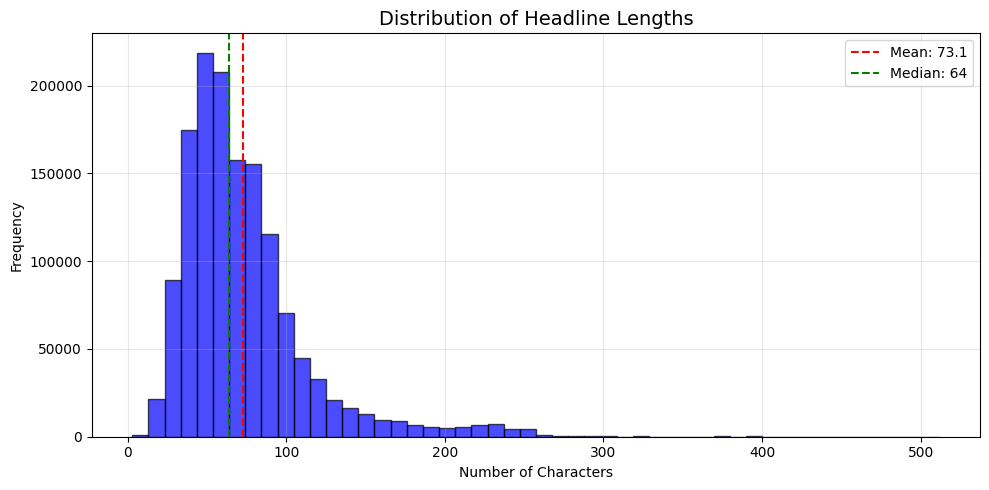

In [4]:
# Calculate headline lengths
df['headline_length']=df['headline'].str.len()
# Statistics

print("Headline Length Statistics")

df['headline_length'].describe()

# # Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['headline_length'], bins=50, color='blue', alpha=0.7, edgecolor='black')
ax.axvline(df['headline_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['headline_length'].mean():.1f}")
ax.axvline(df['headline_length'].median(), color='green', linestyle='--', label=f"Median: {df['headline_length'].median():.0f}")
ax.set_title('Distribution of Headline Lengths', fontsize=14)
ax.set_xlabel('Number of Characters')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#count articles per publisher to ideentify which sources are the most active
publisher_count = df['publisher'].value_counts()
print("Top 10 Publishers by Article Count:")
print(publisher_count.head(10))

Top 10 Publishers by Article Count:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


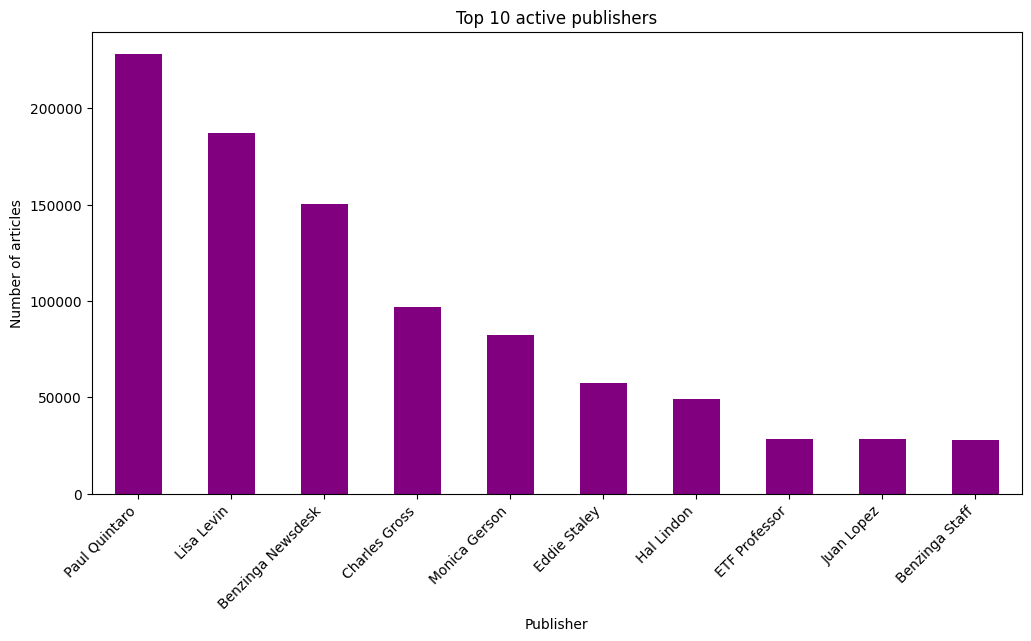

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
publisher_count.head(10).plot(kind='bar',ax=ax,color='purple')
ax.set_title('Top 10 active publishers')
ax.set_xlabel('Publisher')
ax.set_ylabel('Number of articles')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

In [22]:
#publication dates trend
df['date'] = pd.to_datetime(df['date'],utc=True,format='mixed')

In [19]:
print(df['date'].unique()[:5])

<StringArray>
['2020-06-05 10:30:54-04:00', '2020-06-03 10:45:20-04:00',
 '2020-05-26 04:30:07-04:00', '2020-05-22 12:45:06-04:00',
 '2020-05-22 11:38:59-04:00']
Length: 5, dtype: str


In [24]:
df['Year']=df['date'].dt.year
df['Month']=df['date'].dt.month
df['Day']=df['date'].dt.day
df.head(2)

,Unnamed: 0,headline,url,publisher,date,stock,headline_length,Year,Month,Day
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,39,2020,6,5
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,42,2020,6,3


In [28]:
#Articles per day
daily_counts = df.groupby(df['date'].dt.date).size()
print(daily_counts.head(5))

date
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
dtype: int64


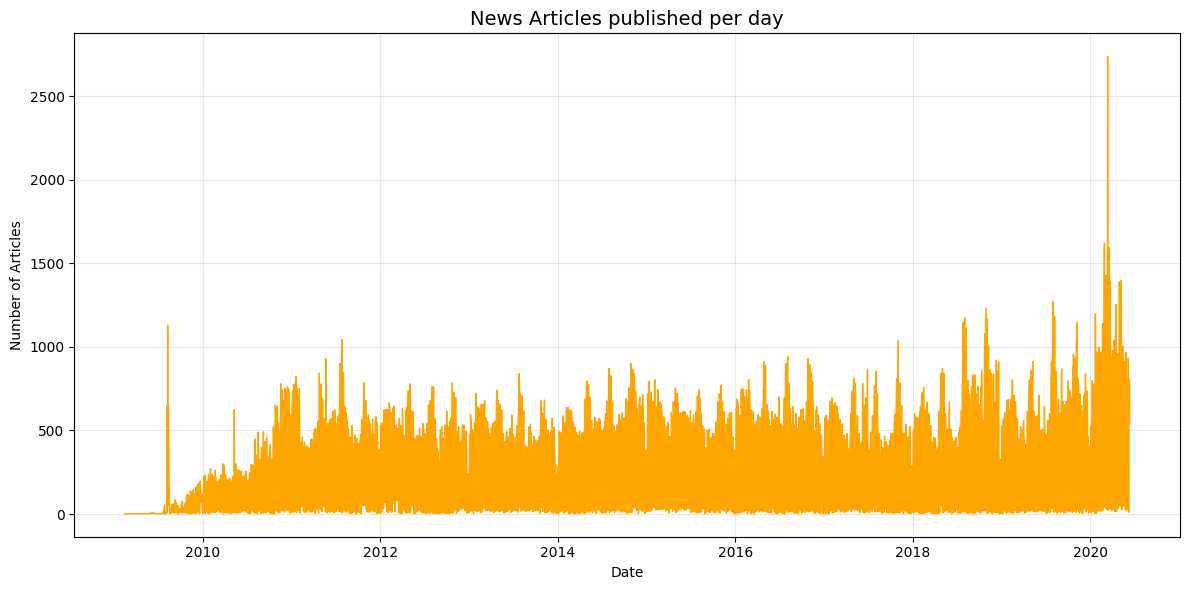

In [30]:
fig,ax=plt.subplots(figsize=(12,6))
ax.plot(daily_counts.index,daily_counts.values,color='orange',linewidth=1)
ax.set_title('News Articles published per day',fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Articles')
ax.grid(True,alpha=0.3)
plt.tight_layout()  
plt.show()